# Tutorial: `context_v3` initialization from raw data

This notebook presents a short, tutorial-style workflow focused only on the initialization step.

It shows how to:
- initialize a `WorkflowContext` from a raw-data directory using `context_v3`,
- inspect detected runs and configurations,
- inspect the dedicated reference stores filled during initialization,
- review warnings and basic sanity checks.

The idea is to keep the notebook focused on a single stage: **load and inspect**.


## 1. Environment setup

This first cell moves the notebook to the repository root and adds `src/` to the `PYTHONPATH`.
This is useful whether the notebook is launched from `notebooks/` or from the repository root.


In [1]:
from pathlib import Path
import os
import sys

%matplotlib inline

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

os.chdir(ROOT)
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"Repository root: {ROOT}")
print(f"Python path includes: {SRC}")


Repository root: /home/achennev/python/scarlet
Python path includes: /home/achennev/python/scarlet/src


## 2. Define the working paths

Here we define:
- the raw-data directory,
- the output directory used for converted files,
- the instrument name passed to the raw-data converter.


In [2]:
from scarlet.workflow.context import initialize_workflow_context_from_raw_directory

RAW_DIR = ROOT / "data" / "SANSLLB" / "raw_june"
OUTPUT_DIR = ROOT / "data" / "SANSLLB" / "out_june_v3"
INSTRUMENT_NAME = "sansllb"

RAW_DIR, OUTPUT_DIR


(PosixPath('/home/achennev/python/scarlet/data/SANSLLB/raw_june'),
 PosixPath('/home/achennev/python/scarlet/data/SANSLLB/out_june_v3'))

## 3. Initialize the `WorkflowContext`

This step scans the raw files, converts them to the SCARLET raw format,
detects runs, builds instrumental configurations, and stores everything in a `WorkflowContext` object.


In [3]:
w = initialize_workflow_context_from_raw_directory(
    RAW_DIR,
    instrument_name=INSTRUMENT_NAME,
    output_dir=OUTPUT_DIR,
    overwrite=True,
)

print(f"runs: {len(w.runs)}")
print(f"configurations: {len(w.configurations)}")
print(f"issues: {len(w.issues)}")
print(f"artifacts: {len(w.artifacts)}")
print(f"output_dir: {w.output_dir}")


runs: 200
configurations: 21
issues: 158
artifacts: 200
output_dir: /home/achennev/python/scarlet/data/SANSLLB/out_june_v3


## 7. Review initialization issues

Warnings collected during initialization are often useful when tuning the automatic classification.


In [4]:
issue_rows = [
    {
        "level": issue.level,
        "where": issue.where,
        "key": issue.key,
        "message": issue.message,
    }
    for issue in w.issues
]

issue_rows[:20]


[{'level': 'WARN',
  'where': 'initialize_workflow_context_from_raw_directory',
  'key': '/home/achennev/python/scarlet/data/SANSLLB/raw_june/sans-llb2026n000906.hdf',
  'message': 'Skipping HDF5 input file with non-2D detector data at /entry0/SANS-LLB/bottom_detector/data (shape=(1, 16, 136))'},
 {'level': 'WARN',
  'where': 'initialize_workflow_context_from_raw_directory',
  'key': '/home/achennev/python/scarlet/data/SANSLLB/raw_june/sans-llb2026n000907.hdf',
  'message': 'Skipping HDF5 input file with non-2D detector data at /entry0/SANS-LLB/bottom_detector/data (shape=(1, 16, 136))'},
 {'level': 'WARN',
  'where': 'initialize_workflow_context_from_raw_directory',
  'key': '/home/achennev/python/scarlet/data/SANSLLB/raw_june/sans-llb2026n000926.hdf',
  'message': 'Skipping HDF5 input file with non-2D detector data at /entry0/SANS-LLB/bottom_detector/data (shape=(11, 16, 136))'},
 {'level': 'WARN',
  'where': 'initialize_workflow_context_from_raw_directory',
  'key': '/home/achennev/

In [5]:
w.runs_table()

sample_name,config_id,mode,entity,thickness,transmission,file_path
H2O,config_1,scattering,water,1,,sans-llb2026n000902.nxs
H2O,config_2,scattering,water,1,,sans-llb2026n000903.nxs
H2O,config_3,scattering,water,1,,sans-llb2026n000904.nxs
H2O,config_4,scattering,water,1,,sans-llb2026n000905.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000908.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000909.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000910.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000911.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000912.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000913.nxs


In [6]:
w.write_runs_table_csv('runs_v3.csv',overwrite=True)

PosixPath('/home/achennev/python/scarlet/runs_v3.csv')

In [7]:
w.update_from_runs_table_csv("/home/achennev/python/scarlet/data/SANSLLB/raw/runs_v3_filtered.csv")
w.compute_transmissions()
w.runs_table()

sample_name,config_id,mode,entity,thickness,transmission,file_path
Cd,config_9,transmission,dark,,,sans-llb2026n000974.nxs
EB,config_9,transmission,empty_beam,,,sans-llb2026n000975.nxs
AgBe,config_9,transmission,sample,1,0.744027,sans-llb2026n000976.nxs
EC,config_9,transmission,empty_cell,,0.868319,sans-llb2026n000977.nxs
H2O,config_9,transmission,water,1,,sans-llb2026n000978.nxs
ludox_AM20,config_9,transmission,sample,1,0.53595,sans-llb2026n000979.nxs
ludox_SM30,config_9,transmission,sample,1,0.555082,sans-llb2026n000980.nxs
ludox_TM50,config_9,transmission,sample,1,0.570916,sans-llb2026n000981.nxs
Cd,config_9,scattering,dark,,,sans-llb2026n000982.nxs
EB,config_9,scattering,empty_beam,,,sans-llb2026n000983.nxs


In [8]:
w.configurations_table()

config_id,wavelength,sample_detector_distance,collimation_distance,last_aperture_to_sample_distance,aperture1,aperture2,notes
config_10,5.00051 A,detector0=2 m; detector1=0.809993 m; detector2=0.809993 m,0.5 m,1.6 m,slit x=0.0499996 m y=0.05 m,slit x=0.0254997 m y=0.0254998 m,
config_9,4.99971 A,detector0=8.00001 m; detector1=2.66667 m; detector2=2.66667 m,1.33333 m,1.6 m,slit x=0.0237499 m y=0.0237499 m,slit x=0.0145619 m y=0.0145621 m,


## Test Pipepline

In [9]:
from scarlet.workflow.pipeline import ReductionPipeline, ReductionState
w.attach_mask_bundles_from_output_dir()
state = ReductionState(sample_name="ludox_TM50",config_id="config_10"
                       , workflow=w, transmission=0.5)
pipe = ReductionPipeline().with_azimuthal_averaging()
state = pipe.run(state)

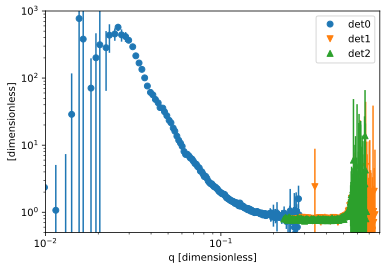

In [19]:
import plopp as pp
# state.detectors[0].plot(logy=True, logx=True, xmin=0.02)
pp.plot({"det0":state.detectors[0], "det1":state.detectors[1],"det2":state.detectors[2]}, 
        xmin=0.01, ymin=0.5, ymax=1000, logx=True, logy=True)

In [11]:
from scarlet.gui import run_mask_editor
# run_mask_editor()

In [12]:
w.build_water_flatfield("config_10")

PosixPath('/home/achennev/python/scarlet/data/SANSLLB/out_june_v3/flatfield_config_10.nxs')

In [13]:
import numpy as np
data = np.load('/home/achennev/python/scarlet/data/SANSLLB/out_june_v3/flatfield_config_10.npz')

In [14]:
state.detectors[0]

<scipp.DataArray>
Dimensions: Sizes[q:200, ]
Coordinates:
* counts                      int64  [dimensionless]  (q)  [1, 1, ..., 4, 1]
* q                         float64  [dimensionless]  (q)  [0.00624052, 0.0087243, ..., 0.277014, 0.279182]
Data:
                            float64  [dimensionless]  (q)  [-2.68217, 0.707949, ..., 1.58873, 0.914973]  [30.22, 3.2163, ..., 0.816182, 0.0402504]

In [15]:
w.attach_mask_bundle(os.path.join(OUTPUT_DIR,"mask_config10.nxs"), config_id="config_10")

'config_10'

In [16]:
state.reductions_steps

['subtract references', 'water normalization', 'azimuthal averaging']

In [17]:
w.flatfields

{}